In [2]:
import hist
from coffea.util import load, save
import mplhep as hep
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
from tabulate import tabulate
import uncertainties as unc  
import uncertainties.unumpy as unumpy 
plt.style.use(hep.style.CMS)


In [51]:
hists = load('./hadmonotoprecoiltrgexpendref.scaled')
year = '2022'
lumi = {
    '2022': 7.98,
    '2023': 17.794
}
histversion = 'recoiltrg'
whathist = {
    'recoiltrg': 'RecoilTrgEff',
    'photrg': 'PhotonTrgEff',
}

In [52]:
from scipy.special import betaincinv # type: ignore

def ClopperPearson(total, passed, level=0.68):
    """
    Clopper-Pearson method for calculating confidence intervals.
    :param total: Array of total events
    :param passed: Array of events that passed the selection
    :param level: Confidence level (0.68 for 1 sigma, 0.95 for 2 sigma, etc.)
    :return: Lower and upper bounds of the confidence interval
    """
    alpha = 1 - level
    lower_bound = betaincinv(passed, total - passed + 1, alpha / 2)
    upper_bound = betaincinv(passed + 1, total - passed, 1 - alpha / 2)
    # nan to 0 for lower bound and 1 for upper bound
    lower_bound = np.where(np.isnan(lower_bound), 0, lower_bound)
    upper_bound = np.where(np.isnan(upper_bound), 1, upper_bound)
    return lower_bound, upper_bound

In [53]:
import numpy as np

def efficiency(num, den):
    num_v = num.values()
    den_v = den.values()



    eff = np.divide(
        num_v, den_v,
        out=np.zeros_like(num_v),
        where=den_v > 0
    )

    err = np.zeros_like(eff)
    mask = den_v > 0

    #err = [np.abs(eff[mask] - err_low[mask]), np.abs(eff[mask] - err_up[mask])],
    err[mask] = np.sqrt(
        eff[mask] * (1 - eff[mask]) / den_v[mask]
    )

    return eff, err

In [54]:
hists['bkg']['recoilpt']
bks_datasets = ['Z ($\\ell\\ell$) + Jets', 'W ($\\ell\\nu$) + Jets']
regions = ['basic', 'muon', 'dimu']
trigger_names = ['IsoMu', 'PFMETNoMu120', 'PFMETNoMu120PFHT60']
print(hists['bkg']['recoilpt'])

{'Z ($\\ell\\ell$) + Jets': Hist(
  StrCategory(['basic', 'dimu'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=1.14404e+08, variance=1.14404e+08) (WeightedSum(value=2.02342e+08, variance=2.02342e+08) with flow), 'W ($\\ell\\nu$) + Jets': Hist(
  StrCategory(['basic', 'muon'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=3.24325e+08, variance=3.24325e+08) (WeightedSum(value=8.17258e+08, vari

In [55]:
hists['data']['recoilpt']
data_datasets = ['Muon']
regions = ['basic', 'muon', 'dimu']
trigger_names = ['IsoMu', 'PFMETNoMu120', 'PFMETNoMu120PFHT60']
print(hists['data']['recoilpt'])

{'Muon': Hist(
  StrCategory(['basic', 'muon', 'dimu'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=1.59661e+08, variance=1.59661e+08) (WeightedSum(value=1.62312e+08, variance=1.62312e+08) with flow)}


In [74]:
region = 'dimu'
if region == 'dimu':
    dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if region == 'muon':
    dataset_mc = 'W ($\\ell\\nu$) + Jets'
dataset_dt = 'Muon'
vari = 'recoilpt'
vari_name = {
    'recoilpt': 'Hadronic Recoil $p_T$ [GeV]',
    'metpt': 'MET $p_T$ [GeV]'
}

In [75]:
PF1_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
num_bkg = (PF1_bkg + PF2_bkg + PF3_bkg)
#num_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
den_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1}].project(vari)#.values()

In [76]:
num_bkg

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=1.46773e+07, variance=1.46773e+07) (WeightedSum(value=1.46993e+07, variance=1.46993e+07) with flow)

In [77]:
den_bkg

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=2.31613e+07, variance=2.31613e+07) (WeightedSum(value=2.31836e+07, variance=2.31836e+07) with flow)

In [78]:
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
PF1_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)
num_data = PF1_data + PF2_data + PF3_data# + PF4_data
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
#den_data = PF1_data + PF2_data + PF3_data + PF4_data #hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)#.values()
den_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)

In [79]:
num_data

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=54868, variance=54868) (WeightedSum(value=54894, variance=54894) with flow)

In [80]:
den_data

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=972772, variance=972772) (WeightedSum(value=975327, variance=975327) with flow)

In [81]:
err_low, err_up = ClopperPearson(den_bkg.values(), num_bkg.values(), level=0.68)
print(err_low)
print(err_up)

[0.         0.00607966 0.14884695 0.73264697 0.96734919 0.9873029
 0.99219976 0.99474385 0.9964229  0.99712108 0.99790445 0.99830813
 0.99874122 0.99876718 0.99886221 0.99881024 0.99886391 0.99901442
 0.99907688 0.99873148 0.99888229 0.9982512  0.99861552 0.99806377]
[1.         0.006158   0.14918382 0.73320212 0.9675728  0.9874822
 0.9924004  0.99490393 0.99652737 0.99722275 0.99801299 0.99840832
 0.99881781 0.99884762 0.99895759 0.99893494 0.9990185  0.9991958
 0.99929573 0.9990495  0.99924725 0.99881393 0.99922269 0.99893699]


In [82]:
data_err_low, data_err_up = ClopperPearson(den_data.values(), num_data.values(), level=0.68)
print(data_err_low)
print(data_err_up)

[0.         0.00119202 0.03458995 0.31609793 0.61904617 0.65303976
 0.55958514 0.4606424  0.38048673 0.29400748 0.27090602 0.16031336
 0.13503857 0.06733537 0.05899617 0.04030074 0.03983147 0.0622479
 0.00197933 0.         0.04951951 0.00300158 0.00322356 0.        ]
[1.         0.00128565 0.03527673 0.31961155 0.62577728 0.6638246
 0.57653115 0.48406833 0.41162599 0.33119951 0.31497024 0.20269437
 0.18709411 0.10956159 0.11074315 0.08966321 0.09438188 0.12476163
 0.03688689 0.02513134 0.12614744 0.0555913  0.05962201 0.03670889]


In [83]:
#print("data num, den")
#print(num_data.values())
#print(den_data.values())
binedges = den_data.axes["recoilpt"].edges
print("%3s  low edge" % str("bin"), "%9s" % str("num"), "%9s" % str("den") )
for i in range(len(den_data.values())):
    print("%3s" % i, "%9s" % binedges[i], "%9s" % list(num_data.values())[i], "%9s" % list(den_data.values())[i] )

bin  low edge       num       den
  0       0.0       0.0       0.0
  1      50.0     717.0  579176.0
  2     100.0    9978.0  285643.0
  3     150.0   22263.0   70042.0
  4     200.0   12955.0   20814.0
  5     250.0    5157.0    7832.0
  6     300.0    1986.0    3496.0
  7     350.0     888.0    1880.0
  8     400.0     411.0    1038.0
  9     450.0     208.0     666.0
 10     500.0     136.0     465.0
 11     550.0      67.0     371.0
 12     600.0      37.0     232.0
 13     650.0      19.0     220.0
 14     700.0      12.0     147.0
 15     750.0       8.0     131.0
 16     800.0       7.0     112.0
 17     850.0      10.0     112.0
 18     900.0       1.0      88.0
 19     950.0       0.0      72.0
 20    1000.0       6.0      74.0
 21    1050.0       1.0      58.0
 22    1100.0       1.0      54.0
 23    1150.0       0.0      49.0


In [84]:
eff_mc,   err_mc   = efficiency(num_bkg, den_bkg)
eff_data, err_data = efficiency(num_data, den_data)
sf = np.divide(
    eff_data, eff_mc,
    out=np.zeros_like(eff_data),
    where=eff_mc > 0
)

In [85]:
sf_err = np.zeros_like(sf)

mask = (eff_mc > 0) & (eff_data > 0)
print(err_data)
print(eff_data)
sf_err = sf[mask] * np.sqrt(
    (err_data[mask] / eff_data[mask])**2 +
    (err_mc[mask]   / eff_mc[mask])**2
)

[0.00000000e+00 4.62040487e-05 3.43539901e-04 1.75943231e-03
 3.36023018e-03 5.35860125e-03 8.37762583e-03 1.15139820e-02
 1.51795414e-02 1.79577972e-02 2.10954102e-02 1.99716216e-02
 2.40373280e-02 1.89382920e-02 2.25829933e-02 2.09213934e-02
 2.28726580e-02 2.69446813e-02 1.12988858e-02 0.00000000e+00
 3.17309082e-02 1.70921005e-02 1.83462495e-02 0.00000000e+00]
[0.         0.00123797 0.03493172 0.31785215 0.6224176  0.6584525
 0.5680778  0.47234043 0.39595376 0.31231231 0.29247312 0.18059299
 0.15948276 0.08636364 0.08163265 0.0610687  0.0625     0.08928571
 0.01136364 0.         0.08108108 0.01724138 0.01851852 0.        ]


ValueError: 'yerr' (shape: (21,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (23,))

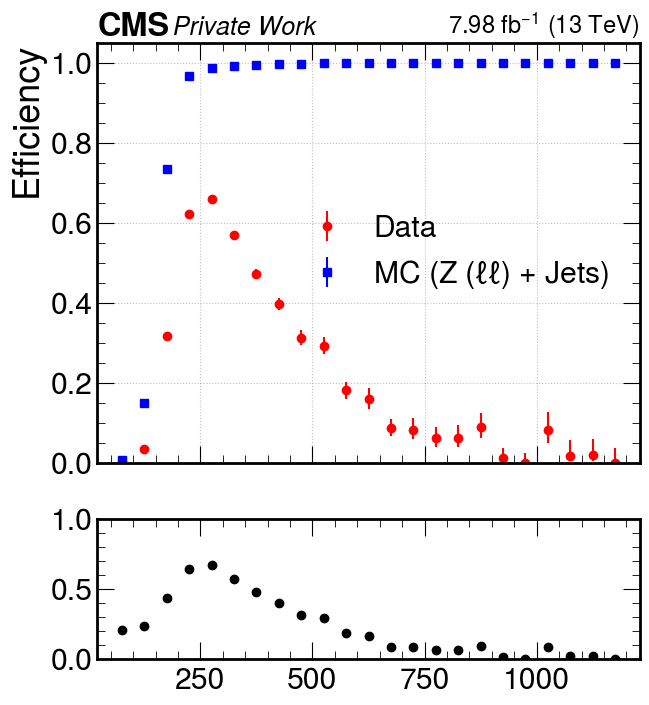

In [86]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num_bkg.axes[vari].centers
mask = (den_bkg.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_data[mask], yerr=[np.abs(eff_data[mask] - data_err_low[mask]), np.abs(eff_data[mask] - data_err_up[mask])],
    fmt='o', label='Data', color='red',
)
ax1.errorbar(
    x[mask], eff_mc[mask], yerr=err_mc[mask],
    fmt='s', label=f'MC ({dataset_mc})', color='blue',
)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
ax2.errorbar(
    x[mask], sf[mask], yerr=sf_err,#[mask],
    fmt='o', color='black'
)

print(err_mc)
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel(f"{vari_name[vari]}")
ax2.set_ylim(0.5, 1.5)
ax2.grid(True)

#ax2.set_xlabel("Recoil $p_T$ [GeV]")
plt.show()
fig.savefig('./plots_recoiltrg/'+whathist[histversion]+'_'+vari+year+'_'+region+'_moreREF.png')

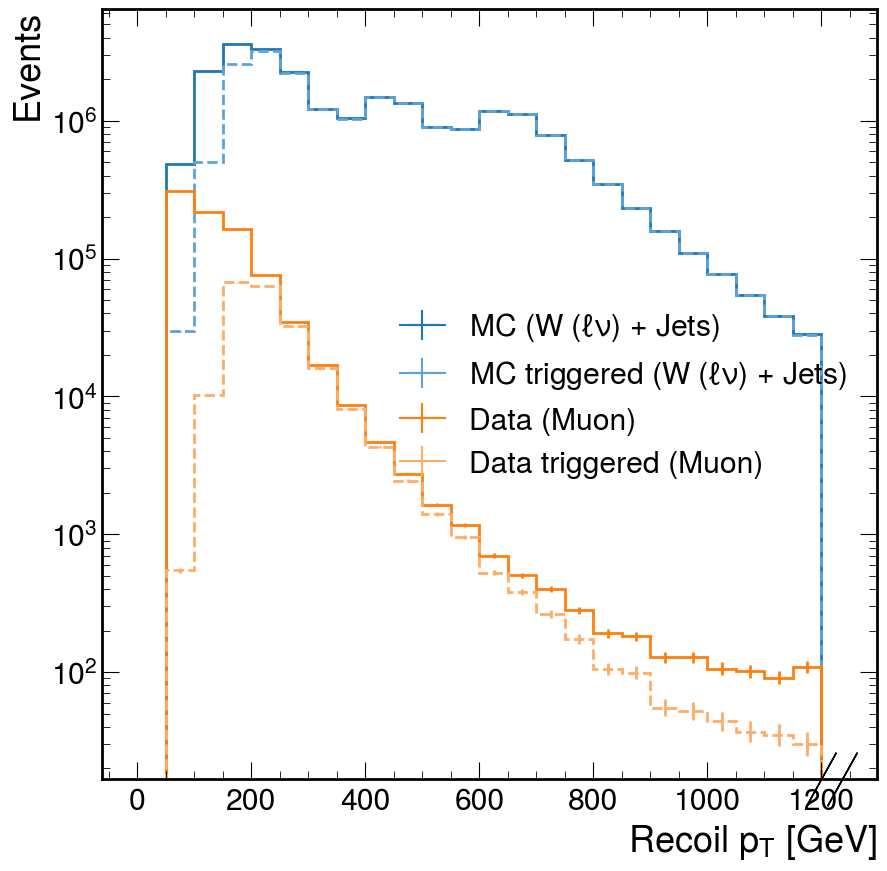

In [73]:
import matplotlib.pyplot as plt
import mplhep as hep

vari = 'recoilpt'
region = 'muon'
if region == 'dimu':
    dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if region == 'muon':
    dataset_mc = 'W ($\\ell\\nu$) + Jets'
dataset_dt = 'Muon'

PF1_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

PF1_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_bkg  = (PF1_bkg + PF2_bkg + PF3_bkg)# + PF4_bkg)
num_data = (PF1_data + PF2_data + PF3_data)# + PF4_data)
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
den_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)#.values()
den_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1}].project(vari)#.values()

pure_data = hists['data'][vari][dataset_dt][{'region':region}].project(vari)
pure_bkg  = hists['bkg'][vari][dataset_mc][{'region':region}].project(vari)

hep.style.use("CMS")

fig, ax = plt.subplots()
#youout = '''
hep.histplot(
    den_bkg,
    ax=ax,
    label=f"MC ({dataset_mc})",
    linewidth=2,
    color="#1f77b4"
)

hep.histplot(
    num_bkg,
    ax=ax,
    label=f"MC triggered ({dataset_mc})",
    linewidth=2,
    color="#5fa2d9",
    linestyle='--'
)
#'''
hep.histplot(
    den_data,
    ax=ax,
    label="Data (Muon)",
    linewidth=2,
    color="#ff7f0e"
)
#b = '''
hep.histplot(
    num_data,
    ax=ax,
    label="Data triggered (Muon) ",
    linewidth=2,
    color="#ffad66",
    linestyle='--'
)
#'''
ax.set_xlabel("Recoil $p_T$ [GeV]")
ax.set_ylabel("Events")
ax.legend()
ax.set_yscale('log')

plt.show()
fig.savefig('./plots_recoiltrg/'+region+'_'+whathist[histversion]+'_'+vari+year+'dist_moreREF_log.png')

## Data or MC only plots

In [87]:
hists = load('./hadmonotoprecoiltrgexpendref.scaled')

year = '2022'
region = 'muon'
only = 'data'
#dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if only == 'bkg':
    dataset_one = 'W ($\\ell\\nu$) + Jets'
else:
    dataset_one = 'Muon'
vari = 'recoilpt'
PF1_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_one = PF1_one + PF2_one + PF3_one# + PF4_data
den_one = PF1_one + PF2_one + PF3_one + PF4_one 

In [88]:
one_err_low, one_err_up = ClopperPearson(den_one.values(), num_one.values(), level=0.68)


eff_one, err_one = efficiency(num_one, den_one)


In [89]:
binedges = den_one.axes["recoilpt"].edges
print("%3s  low edge" % str("bin"), "%9s" % str("num"), "%9s" % str("den") )
for i in range(len(den_one.values())):
    print("%3s" % i, "%9s" % binedges[i], "%9s" % list(num_one.values())[i], "%9s" % list(den_one.values())[i] )

bin  low edge       num       den
  0       0.0       0.0       0.0
  1      50.0     547.0  311676.0
  2     100.0   10177.0  216555.0
  3     150.0   67050.0  164834.0
  4     200.0   62979.0   76182.0
  5     250.0   32496.0   34675.0
  6     300.0   15996.0   16885.0
  7     350.0    8156.0    8701.0
  8     400.0    4283.0    4700.0
  9     450.0    2447.0    2730.0
 10     500.0    1402.0    1634.0
 11     550.0     952.0    1165.0
 12     600.0     526.0     698.0
 13     650.0     379.0     504.0
 14     700.0     265.0     399.0
 15     750.0     174.0     280.0
 16     800.0     105.0     191.0
 17     850.0      99.0     182.0
 18     900.0      55.0     128.0
 19     950.0      52.0     128.0
 20    1000.0      44.0     106.0
 21    1050.0      37.0     101.0
 22    1100.0      35.0      91.0
 23    1150.0      30.0     108.0


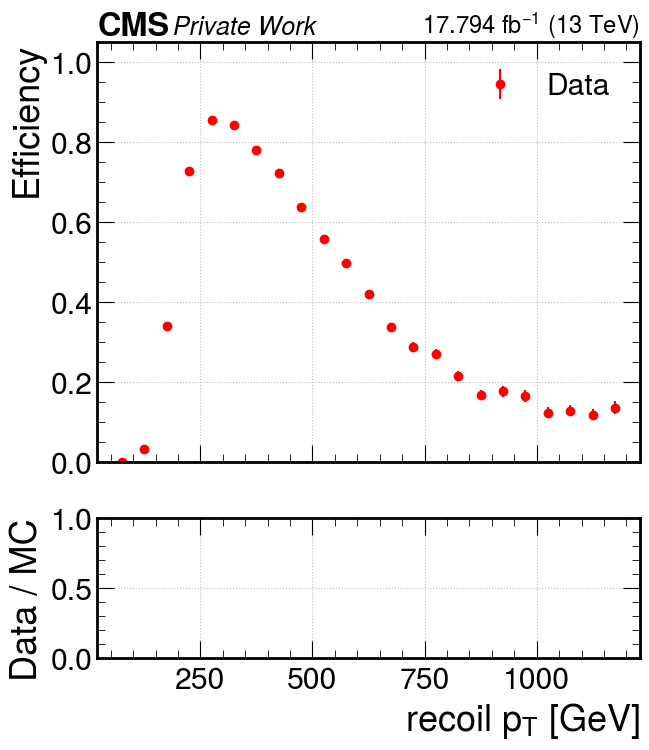

In [119]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num_one.axes[vari].centers
mask = (den_one.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_one[mask], yerr=[np.abs(eff_one[mask] - one_err_low[mask]), np.abs(eff_one[mask] - one_err_up[mask])],
    fmt='o', label='Data', color='red',
)
#ax1.errorbar(
#    x[mask], eff_mc[mask], yerr=err_mc[mask],
#    fmt='s', label=f'MC ({dataset_mc})', color='blue',
#)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
#ax2.errorbar(
#    x[mask], sf[mask], yerr=sf_err,#[mask],
#    fmt='o', color='black'
#)

ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel("recoil $p_T$ [GeV]")
#ax2.set_ylim(0.95, 1.05)
ax2.grid(True)

#ax2.set_xlabel("Recoil $p_T$ [GeV]")
plt.show()
fig.savefig('./plots_recoiltrg/eleTrgEff_'+region+'_'+whathist[histversion]+'_'+vari+year+'_data.png')

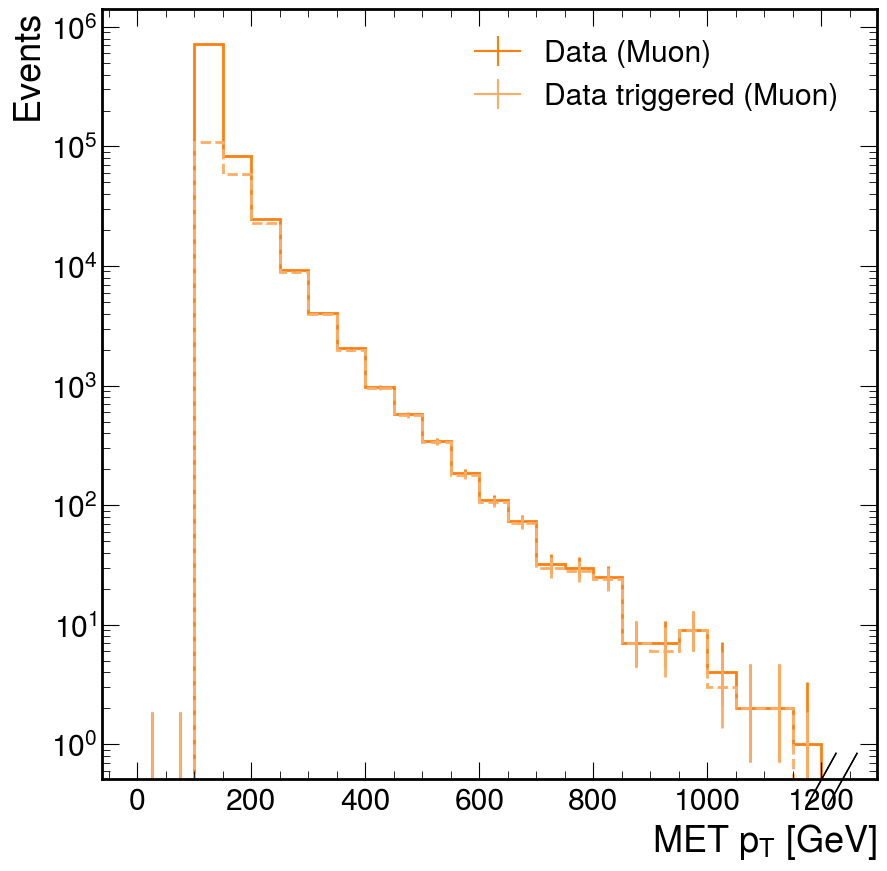

In [92]:
import matplotlib.pyplot as plt
import mplhep as hep

vari = 'metpt'
region = 'muon'

PF1_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_one = PF1_one + PF2_one + PF3_one# + PF4_data
den_one = PF1_one + PF2_one + PF3_one + PF4_one 
hep.style.use("CMS")

fig, ax = plt.subplots()
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

hep.histplot(
    den_one,
    ax=ax,
    label="Data (Muon)",
    linewidth=2,
    color="#ff7f0e"
)
#b = '''
hep.histplot(
    num_one,
    ax=ax,
    label="Data triggered (Muon) ",
    linewidth=2,
    color="#ffad66",
    linestyle='--'
)

#'''
ax.set_xlabel("MET $p_T$ [GeV]")
ax.set_ylabel("Events")
ax.legend()
ax.set_yscale('log')

plt.show()
fig.savefig('./plots_recoiltrg/'+region+'_'+whathist[histversion]+'_'+vari+year+'dist_moreREF_data_log.png')

## No

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from cycler import cycler
plt.style.use(hep.style.CMS)


region = 'muon'
key = 'dimupt'



fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,10),
    gridspec_kw={"height_ratios": (3, 1)},
    sharex=True
)

fig.subplots_adjust(hspace=.07)
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)')
ax.set_prop_cycle(cycler(color=colors[stack_map]))

hep.histplot(
    den_bkg,
    ax=ax,
    label="MC (W+Jets)",
    linewidth=2,
    color="#1f77b4"
)

hep.histplot(
    num_bkg,
    ax=ax,
    label="MC triggered (W+Jets) ",
    linewidth=2,
    color="#5fa2d9",
    linestyle='--'
)

hep.histplot(
    den_data,
    ax=ax,
    label="Data (JetMET)",
    linewidth=2,
    color="#ff7f0e"
)
#b = '''
hep.histplot(
    num_data,
    ax=ax,
    label="Data triggered (JetMET) ",
    linewidth=2,
    color="#ffad66",
    linestyle='--'
)


error_opts = {
    'step': 'post',
    'label': 'Stat. Unc.',
    'hatch': '///',
    'facecolor': 'None',
    'edgecolor': (0, 0, 0, 0.3),
    'linewidth': 0
}
#unc_low =  mcstack.view().value - np.sqrt(mcstack.view().variance)
#unc_high = mcstack.view().value + np.sqrt(mcstack.view().variance)
#ax.fill_between(bins[:-1], unc_low, unc_high, **error_opts)



leg = ax.legend(ncol=3, loc='upper left', fontsize=12, title= leg_reg[region])
ax.set_yscale('log')
ax.set_ylim(0.01, 1000000)
ax.set_xlabel(None)
#rax.set_xlabel(key)


ratio_datdda = np.divide(
    num_data, den_data,
    out=np.zeros_like(num_data),
    where= den_data > 0
)

rax.errorbar(
    x=target.axes.edges[0][:-1] + np.diff(target.axes.edges[0]) / 2,
    y=ratio,
    yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
    fmt="o",
    color="k",
)



if not key == 'template':
    lab = bkg[key][sample].axes[key].label
    rax.set_xlabel(lab)
rax.set_ylabel('Dacta/MC')#
rax.set_ylim(0.5, 1.5)
#rax.set_xlim(target.axes.edges[0][0], target.axes.edges[0][-1])
#rax.set_xlim(ratio.min(), ratio.max())
rax.axhline(1, color='k', linestyle='--',alpha=0.5)
rax.grid(True)

fig.savefig('./plotseff_'+whathist[histversion]+'/'+region+'_'+key+'_'+whathist[histversion]+'.png')